# GSFM Dex Benchmark

Based on the paper and the RNA-seq Data notebook
<https://maayanlab.github.io/dex-benchmark/index.html>
Specifically: <https://maayanlab.github.io/dex-benchmark/Benchmarking_RNA-seq_DEG_Methods/benchmarking_RNAseq_DEGs.html>

We've reproduced the benchmark but also leveraged the GSFM model to augment the enrichment analysis. The benchmark uses fishers exact tests to do over representation analysis comparing differentially expressed gene sets with gene sets in the ChEA 2022 library. A good Enrichment Analysis method will rank known transcription factor more highly.

We extend this benchmark in a couple of ways:

1. Using GSFM, we augment the gene sets obtained from differential expression analysis and use the fisher method.
2. Using GSFM, we augment the gene sets in the ChEA 2022 library.
3. We use blitzgsea on top of the fisher method.
4. Using GSFM, we can assign significance of all genes building a pseudo-signature which can be used with blitzgsea. This is a way of doing GSEA given an arbitrary set for which we don't have the original significance values.

# Benchmarking RNA-seq DEG Methods with the Dexamethasone Benchmarking Resource

This notebook reads in designated meta data and RNA-seq expression data files from a dexamethasone study and performs two DEG methods, characteristic direction and log fold change, on the data using code adapted from Bulk RNA-seq Analysis pipeline appyter: https://appyters.maayanlab.cloud/Bulk_RNA_seq/

The results of the DEG methods are benchmarked after enrichment analysis focused on the NR3C1 transcription factor, the known target of dexamethasone.

In [1]:
# Import libraries
import os
import pathlib
import pandas as pd
import numpy as np
import plotly.graph_objects as go
import requests
import scipy.stats as ss
from maayanlab_bioinformatics.normalization.filter import filter_by_expr
from maayanlab_bioinformatics.dge.characteristic_direction import characteristic_direction
from maayanlab_bioinformatics.dge.limma_voom import limma_voom_differential_expression
from maayanlab_bioinformatics.enrichment import enrich_crisp
from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats
from math import log2, ceil
from IPython.display import display, Markdown
from random import sample
from maayanlab_bioinformatics.plotting.bridge import bridge_plot
import matplotlib.pyplot as plt
import matplotlib as mpl
from sklearn.metrics import pairwise_distances
import seaborn as sns


In [2]:
import warnings
warnings.filterwarnings('ignore')

# Load in Data

Using data from GEO from the study ["Development of a glucocorticoid exposure signature for SLE" (GSE159094)](https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE159094)

In [3]:
# Set all variables
meta_class_column_name = 'Class'
control_name = 'Control'
treatment_name = 'Dex'

data_dir = 'dex-benchmark/RNAseq_data'
gse = 'GSE159094'
meta_data_filename = f'{gse}_series_matrix.txt'
rnaseq_data_filename = f'{gse}_counts.txt'

In [4]:
# Load in metadata
try:
    if meta_data_filename.endswith('.csv'): 
        meta_df = pd.read_csv(f"{data_dir}/{meta_data_filename}", index_col=0)
    else:
        meta_df = pd.read_csv(f"{data_dir}/{meta_data_filename}", sep="\t", index_col=0)
    print(f"Metadata file shape: {meta_df.shape[0]} samples, {meta_df.shape[1]} features")
except:
    print("Error! Please ensure the metadata file is in CSV, TXT, or TSV format.")

# Load in data
try:
    if rnaseq_data_filename.endswith('.csv'): 
        expr_df = pd.read_csv(f"{data_dir}/{rnaseq_data_filename}", index_col=0).sort_index()
    else:
        expr_df = pd.read_csv(f"{data_dir}/{rnaseq_data_filename}", sep="\t", index_col=0).sort_index()
    print(f"RNA-seq data file shape: {expr_df.shape[0]} genes, {expr_df.shape[1]} samples")
except:
    print("Error! Please ensure the RNA-seq file is in CSV, TXT, or TSV format.")

# Match samples between the metadata and the dataset
if meta_class_column_name not in meta_df.columns:
    print(f"Error! Column '{meta_class_column_name}' was not found in the metadata.")

shared_samples = set(meta_df.index).intersection(expr_df.columns)
meta_df = meta_df[meta_df.index.isin(shared_samples)]
meta_df = pd.concat([
    meta_df[meta_df['Class'] == control_name],
    meta_df[meta_df['Class'] == treatment_name]
]) 
expr_df = expr_df[meta_df.index]
print(f"\nThe pipeline will be run on {len(shared_samples)} samples.")

Metadata file shape: 8 samples, 2 features
RNA-seq data file shape: 27780 genes, 8 samples

The pipeline will be run on 8 samples.


In [5]:
## Filter out non-expressed genes
expr_df = expr_df.loc[expr_df.sum(axis=1) > 0, :]
## Filter out lowly expressed genes
expr_df = filter_by_expr(expr_df, group=meta_df[meta_class_column_name].apply(lambda x: x==treatment_name))
print(f"Number of genes after filtering by low expression: {expr_df.shape[0]}")

Number of genes after filtering by low expression: 15376


In [6]:
# Display meta data
meta_df

,Class,Pair
Sample_geo_accession,,
GSM4819298,Control,A
GSM4819299,Control,B
GSM4819300,Control,C
GSM4819301,Control,D
GSM4819286,Dex,A
GSM4819287,Dex,B
GSM4819288,Dex,C
GSM4819289,Dex,D


In [7]:
# Display expression data
expr_df

,GSM4819298,GSM4819299,GSM4819300,GSM4819301,GSM4819286,GSM4819287,GSM4819288,GSM4819289
Gene,,,,,,,,
A1BG,47,34,81,68,47,43,64,108
A1BG-AS1,100,39,131,138,115,64,128,136
A2M,86,152,67,63,142,183,52,76
A2M-AS1,11,7,6,2,9,13,15,10
A4GALT,58,46,23,126,96,47,26,146
...,...,...,...,...,...,...,...,...
ZXDC,1172,1433,1091,1161,1241,1320,1219,1617
ZYG11B,586,400,584,558,568,609,609,816
ZYX,8578,16603,5281,7752,8013,12881,4818,8480


# Differential Gene Expression Methods

In [8]:
signatures = {}

In [9]:
pathlib.Path(f'{data_dir}/signatures/{gse}').mkdir(exist_ok=True)

### Characteristic Direction

In [10]:
# Function for computing signatures with characteristic direction
def cd_signature(control, treatment, data, metadata, meta_class_column_name):
    
    ctrl_ids = metadata.loc[metadata[meta_class_column_name]==control, :].index.tolist() #control
    case_ids = metadata.loc[metadata[meta_class_column_name]==treatment,:].index.tolist() #case
    
    signature = characteristic_direction(
        data.loc[:, ctrl_ids], 
        data.loc[:, case_ids], 
        calculate_sig=True
    )
    signature = signature.sort_values("CD-coefficient", ascending=False)
    signature['Significance'] = signature['CD-coefficient'].apply(abs)
    
    return signature

# if not os.path.exists(f'{data_dir}/signatures/{gse}/cd.tsv'): 
signatures['cd'] = cd_signature(control_name, treatment_name, expr_df, meta_df, meta_class_column_name)
signatures['cd'].to_csv(f'{data_dir}/signatures/{gse}/cd.tsv', sep='\t')
# else:
#     signatures['cd'] = pd.read_csv(f'{data_dir}/signatures/{gse}/cd.tsv', sep='\t', index_col=0)
display(Markdown(f"Characteristic Direction Signature"))
display(signatures['cd'][['CD-coefficient']])

Characteristic Direction Signature

,CD-coefficient
Gene,
TXNIP,0.598894
THBS1,0.388535
ETS1,0.184504
TSC22D3,0.169194
FKBP5,0.150122
...,...
TGFBI,-0.088838
FTH1,-0.090782
B2M,-0.112363


## Limma-Voom

In [11]:
# Function for computing signatures
def limma(control, treatment, data, metadata, meta_class_column_name):

    ctrl_ids = metadata.loc[metadata[meta_class_column_name] == control, :].index.tolist()  # control
    case_ids = metadata.loc[metadata[meta_class_column_name] == treatment, :].index.tolist()  # case

    # run limma
    signature = limma_voom_differential_expression(
        data.loc[:, ctrl_ids],
        data.loc[:, case_ids],
        voom_design=True,
        filter_genes=False
    )
    signature = signature.sort_values("t", ascending=False)
    signature['Significance'] = signature['P.Value']
    signature['StatVal'] = signature['t'].apply(abs)

    # return result
    return signature

# if not os.path.exists(f'{data_dir}/signatures/{gse}/limma-voom.tsv'): 
signatures['limma'] = limma(control_name, treatment_name, expr_df, meta_df, meta_class_column_name)
signatures['limma'].to_csv(f'{data_dir}/signatures/{gse}/limma.tsv', sep='\t')
# else:
#     signatures['limma'] = pd.read_csv(f'{data_dir}/signatures/{gse}/limma-voom.tsv', sep='\t', index_col=0)
display(Markdown(f"Limma-voom Signature"))
display(signatures['limma'].drop(columns=['Significance', 'StatVal']))

Limma-voom Signature

,logFC,AveExpr,t,P.Value,adj.P.Val,B
gene_symbol,,,,,,
TRERF1,1.825465,4.508545,13.291168,5.187956e-07,0.004934,6.894803
KLF9,1.867456,6.560516,12.878515,6.717834e-07,0.004934,6.714460
LRRK2,2.912159,6.192054,12.258192,1.005224e-06,0.004934,6.317300
ZBTB16,3.670881,4.851185,11.661825,1.507455e-06,0.004934,5.866904
LINC02207,3.464744,0.844296,11.194183,2.098745e-06,0.004934,4.298915
...,...,...,...,...,...,...
TLR10,-1.285433,2.091784,-7.367492,5.522794e-05,0.014898,2.384327
RGS16,-2.211374,2.980781,-7.487366,4.891621e-05,0.014191,2.527091
TRAF1,-1.407711,6.755081,-7.853439,3.407249e-05,0.012474,2.782042


### DESeq2 (via pyDESeq2)

In [12]:
# Function for computing signatures with pyDESeq2
def deseq2(data, metadata, meta_class_column_name):
    dds = DeseqDataSet(
        counts=data.T,
        metadata=metadata,
        design_factors=meta_class_column_name
    )
    dds.deseq2()
    signature = DeseqStats(dds, contrast=(meta_class_column_name, 'Dex', 'Control'))
    return signature

# if not os.path.exists(f'{data_dir}/signatures/{gse}/pydeseq2.tsv'): 
signatures['pydeseq2'] = deseq2(expr_df, meta_df, meta_class_column_name)
signatures['pydeseq2'].summary()
signatures['pydeseq2'].results_df['Significance'] = signatures['pydeseq2'].results_df['pvalue']
signatures['pydeseq2'].results_df['StatVal'] = signatures['pydeseq2'].results_df['stat'].apply(abs)
signatures['pydeseq2'] = signatures['pydeseq2'].results_df.sort_values(by=['stat'], ascending=False)
signatures['pydeseq2'].to_csv(f'{data_dir}/signatures/{gse}/pydeseq2.tsv', sep='\t')
# else:  
#     signatures['pydeseq2'] = pd.read_csv(f'{data_dir}/signatures/{gse}/pydeseq2.tsv', sep='\t', index_col=0).drop(columns=['BridgeVal'])
#     display(Markdown(f"pyDESeq2 Signature"))
#     display(signatures['pydeseq2'])

Using None as control genes, passed at DeseqDataSet initialization


Fitting size factors...
... done in 0.00 seconds.

Fitting dispersions...
... done in 0.56 seconds.

Fitting dispersion trend curve...
... done in 0.18 seconds.

Fitting MAP dispersions...
... done in 0.67 seconds.

Fitting LFCs...
... done in 0.62 seconds.

Calculating cook's distance...
... done in 0.01 seconds.

Replacing 0 outlier genes.

Running Wald tests...


Log2 fold change & Wald test p-value: Class Dex vs Control
             baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
Gene                                                                         
A1BG        60.268470        0.095760  0.349194  0.274232  0.783906  0.999952
A1BG-AS1   105.669663        0.067365  0.398424  0.169080  0.865734  0.999952
A2M        104.645454        0.299210  0.494298  0.605323  0.544965  0.998323
A2M-AS1      9.196878        0.824300  0.572919  1.438773  0.150215  0.690015
A4GALT      68.671378        0.221482  0.583040  0.379874  0.704039  0.999952
...               ...             ...       ...       ...       ...       ...
ZXDC      1278.353808        0.100737  0.123172  0.817857  0.413439  0.970046
ZYG11B     587.352193        0.235630  0.146614  1.607144  0.108023  0.595369
ZYX       9124.450095       -0.189578  0.416303 -0.455386  0.648832  0.999952
ZZEF1     4119.306199        0.011666  0.062947  0.185334  0.852967  0.999952
ZZZ3 

... done in 0.51 seconds.



### Wilcoxon Rank Sum Test

In [13]:
def ranksum(control, treatment, data, metadata, meta_class_column_name):
  res_array = []
  ctrl_ids = metadata.loc[metadata[meta_class_column_name]==control, :].index.tolist()
  case_ids = metadata.loc[metadata[meta_class_column_name]==treatment,:].index.tolist() #case
  for gene in data.index: 
    res = ss.ranksums(
      data.loc[gene, case_ids],
      data.loc[gene, ctrl_ids]
    )
    res_array.append([gene, res.statistic, res.pvalue])
  signature = pd.DataFrame(
    res_array, columns=['Geneid', 'Statistic', 'Pvalue']
  ).set_index('Geneid')
  signature['Significance'] = signature['Pvalue']
  signature['StatVal'] = signature['Statistic'].apply(abs)
  return signature.sort_values(by=['Statistic'], ascending=False)

if expr_df.shape[1] >= 32:
  if not os.path.exists(f'{data_dir}/signatures/{gse}/ranksum.tsv'): 
    signatures['ranksum'] = ranksum(control_name, treatment_name, expr_df, meta_df, meta_class_column_name)
    signatures['ranksum'].to_csv(f'{data_dir}/signatures/{gse}/ranksum.tsv', sep='\t')
  else:
    signatures['ranksum'] = pd.read_csv(f'{data_dir}/signatures/{gse}/ranksum.tsv', sep='\t', index_col=0)
  display(Markdown(f"Wilcoxon Rank-Sum Test"))
  display(signatures['ranksum'].drop(columns=['Significance', 'StatVal']))
else:
  print("Sample sizes <16 generally do not provide good results -- Wilcoxon Rank Sum is skipped. ")

Sample sizes <16 generally do not provide good results -- Wilcoxon Rank Sum is skipped. 


### Welch's t-test

In [14]:
def ttest(control, treatment, data, metadata, meta_class_column_name):
  res_array = []
  ctrl_ids = metadata.loc[metadata[meta_class_column_name]==control, :].index.tolist()
  case_ids = metadata.loc[metadata[meta_class_column_name]==treatment,:].index.tolist() #case
  for gene in data.index: 
    res = ss.ttest_ind(
      data.loc[gene, case_ids],
      data.loc[gene, ctrl_ids],
      equal_var = False
    )
    res_array.append([gene, res.statistic, res.pvalue])
  signature = pd.DataFrame(
    res_array, columns=['Geneid', 'Statistic', 'Pvalue']
  ).set_index('Geneid')
  signature['Significance'] = signature['Pvalue']
  signature['StatVal'] = signature['Statistic'].apply(abs)
  return signature.sort_values(by=['Statistic'], ascending=False)

# if not os.path.exists(f'{data_dir}/signatures/{gse}/ttest.tsv'): 
signatures['ttest'] = ttest(control_name, treatment_name, expr_df, meta_df, meta_class_column_name)
signatures['ttest'].to_csv(f'{data_dir}/signatures/{gse}/ttest.tsv', sep='\t')
# else:
#   signatures['ttest'] = pd.read_csv(f'{data_dir}/signatures/{gse}/ttest.tsv', sep='\t', index_col=0)
display(Markdown(f"Welch's t-test"))
display(signatures['ttest'].drop(columns=['StatVal', 'Significance']))

Welch's t-test

,Statistic,Pvalue
Geneid,,
MIR6883,13.578695,0.000077
ADRB2,12.976908,0.000027
KLRD1,11.149057,0.000036
TRERF1,10.878677,0.000643
NGFR,10.118823,0.000108
...,...,...
GPR15,-7.701463,0.000406
ABAT,-8.150563,0.000503
CD207,-8.198041,0.000583


### (log2) Fold Change

In [15]:
# Function for computing signatures with fold change
def logFC(control, treatment, data, metadata, meta_class_column_name):
    ctrl_ids = metadata.loc[metadata[meta_class_column_name]==control, :].index.tolist()
    case_ids = metadata.loc[metadata[meta_class_column_name]==treatment,:].index.tolist() #case
    signature = data.loc[:, case_ids].mean(axis=1) / (data.loc[:, ctrl_ids].mean(axis=1) + 0.001)
    signature_df = pd.DataFrame(
        signature.apply(lambda x: log2(x+0.001)) \
        .sort_values(ascending=False), columns=['logFC']
    )
    signature_df['Significance'] = signature_df['logFC'].apply(abs)
    return signature_df

# if not os.path.exists(f'{data_dir}/signatures/{gse}/logfc.tsv'):
signatures['logfc'] = logFC(control_name, treatment_name, expr_df, meta_df, meta_class_column_name)
signatures['logfc'].to_csv(f'{data_dir}/signatures/{gse}/logfc.tsv', sep='\t')
# else:
#     signatures['logfc'] = pd.read_csv(f'{data_dir}/signatures/{gse}/logfc.tsv', sep='\t', index_col=0)
display(Markdown("Log Fold Change Signature"))
display(signatures['logfc'].drop(columns=['Significance']))

Log Fold Change Signature

,logFC
Gene,
LINC01736,14.269565
LOC100131496,12.358102
ALOX15B,8.811228
GLDN,7.005479
VSTM2L,6.676612
...,...
PTGS2,-5.019101
CCL7,-5.332820
IL1A,-5.484828


# Enrichment Analysis with Enrichr

The function below uses an offline version of Enrichr to compute enrichment analysis. 

In [16]:
# Get gene lists to put into Enrichr
gene_lists = {'up': {}, 'down': {}, 'combined': {}}
for method in signatures.keys():
    if method == 'ranksum' and expr_df.shape[1] < 16: continue
    gene_lists['up'][method] = signatures[method].head(100).index.tolist()
    gene_lists['down'][method] = signatures[method].tail(100).index.tolist()
    gene_lists['combined'][method] = gene_lists['up'][method] + gene_lists['down'][method]

In [17]:
# Function to get Enrichr Results

def getEnrichrLibrary(library_name): 
    ENRICHR_URL = f'https://maayanlab.cloud/Enrichr/geneSetLibrary?mode=json&libraryName={library_name}'
    resp = requests.get(ENRICHR_URL)
    if not resp.ok: 
        raise Exception(f"Error downloading {library_name} library from Enrichr, please try again.")
    return resp.json()[library_name]['terms']

def getLibraryIter(libdict):
    for k,v in libdict.items():
        if type(v) == list:
            yield k, v
        else:
            yield k, list(v.keys())

def enrich(gene_list, lib_json, name): 
    gene_list = [x.upper() for x in gene_list]
    all_terms = list(lib_json.keys())
    termranks = []
    enrich_res = enrich_crisp(gene_list, getLibraryIter(lib_json), 20000, False)
    enrich_res = [[r[0], r[1].pvalue] for r in enrich_res]
    sorted_res = sorted(enrich_res, key=lambda x: x[1])
    for i in range(len(sorted_res)): 
        termranks.append([name, sorted_res[i][0], i])
    for t in set(all_terms).difference([x[1] for x in termranks]): 
        i+=1
        termranks.append([name, t, i])
    return pd.DataFrame(termranks, columns=['Gene_Set', 'Term', 'Rank'])

In [ ]:
import torch
from gsfm import Vocab, GSFM
# load gsfm vocabulary and model weights
gsfm = GSFM.from_pretrained('maayanlab/gsfm-rummagene').to('cuda')
vocab = Vocab.from_pretrained('maayanlab/gsfm-rummagene')
gsfm.eval()

GSFM(
  (encoder): MLP(
    (layers): ModuleList(
      (0): Linear(in_features=19589, out_features=512, bias=True)
      (1): ReLU()
      (2): Dropout(p=0.2, inplace=False)
      (3): Linear(in_features=512, out_features=256, bias=True)
    )
  )
  (decoder): MLP(
    (layers): ModuleList(
      (0): Linear(in_features=256, out_features=256, bias=True)
      (1): ReLU()
      (2): Dropout(p=0.2, inplace=False)
      (3): Linear(in_features=256, out_features=19589, bias=True)
    )
  )
)

In [20]:
from tqdm.auto import tqdm

def chunked(L, cs):
  C = []
  for item in L:
    C.append(item)
    if len(C) >= cs:
      yield C
      C = []
  if C: yield C

def gsfm_gsl_to_signature(gene_set_library, batch_size=128):
    signature = {}
    for items in chunked(tqdm(gene_set_library.items()), batch_size):
      terms, gene_lists = zip(*items)
      token_ids = torch.nn.utils.rnn.pad_sequence([torch.tensor(vocab(gene_list)) for gene_list in gene_lists], batch_first=True, padding_value=1)
      logits = gsfm(token_ids.to(gsfm.device)).cpu().detach().numpy()
      for i, term in enumerate(terms):
          signature[term] = dict(zip(vocab.vocab, logits[i, :]))
    return signature

def signature_to_rll(signature):
  rll = {}
  for term in signature:
    _, rl = zip(*sorted([(score, g) for g, score in signature[term].items()], reverse=True))
    rll[term] = rl
  return rll

def rll_topk(rll, top_k=100):
  gsl = {}
  for term in rll:
    gsl[term] = rll[term][:top_k]
  return gsl

In [21]:
for dir, gmt in tqdm(gene_lists.items()):
  rll = signature_to_rll(gsfm_gsl_to_signature(gmt))
  for k in tqdm((50, 100, 200)):
    for term, gs in tqdm(rll_topk(rll, k).items()):
      gmt[f"{term}_gsfm_{k}"] = gs

100%|██████████| 5/5 [00:00<00:00, 127875.12it/s]

100%|██████████| 5/5 [00:00<00:00, 167772.16it/s]

100%|██████████| 5/5 [00:00<00:00, 121927.44it/s]

100%|██████████| 5/5 [00:00<00:00, 218453.33it/s]

100%|██████████| 5/5 [00:00<00:00, 195995.51it/s]

100%|██████████| 5/5 [00:00<00:00, 192399.27it/s]

100%|██████████| 5/5 [00:00<00:00, 216201.24it/s]

100%|██████████| 5/5 [00:00<00:00, 170500.16it/s]

100%|██████████| 5/5 [00:00<00:00, 218453.33it/s]

100%|██████████| 3/3 [00:00<00:00,  7.40it/s]


In [22]:
chea2022 = getEnrichrLibrary('ChEA_2022')

In [23]:
benchmark_libs = {"chea2022": chea2022}
chea2022_signature = gsfm_gsl_to_signature(chea2022)
chea2022_rll = signature_to_rll(chea2022_signature)
for k in tqdm((50, 100, 200)):
  benchmark_libs[f"chea2022_gsfm_{k}"] = {
    term: {g: 1 for g in gs} for term, gs in rll_topk(chea2022_rll, k).items()
  }

100%|██████████| 3/3 [00:00<00:00, 223.79it/s]


In [24]:
# blitz gsea methods
import blitzgsea as blitz

In [25]:
signatures.keys()

dict_keys(['cd', 'limma', 'pydeseq2', 'ttest', 'logfc'])

In [26]:
signatures['cd']['score'] = signatures['cd']['CD-coefficient']
signatures['limma']['score'] = signatures['limma']['StatVal']
signatures['pydeseq2']['score'] = signatures['pydeseq2']['StatVal']
signatures['ttest']['score'] = signatures['ttest']['StatVal']
signatures['logfc']['score'] = signatures['logfc']['Significance']

In [27]:
# Get results
chea2022_results = []

for b, l in benchmark_libs.items():
    print(b)
    up_gsfm_signatures = pd.DataFrame(gsfm_gsl_to_signature(gene_lists['up']))
    down_gsfm_signatures = pd.DataFrame(gsfm_gsl_to_signature(gene_lists['down']))
    combined_gsfm_signatures = pd.DataFrame(gsfm_gsl_to_signature(gene_lists['combined']))
    for m in signatures:
        # gsfm scores on gene set followed by gsea
        results = blitz.gsea(up_gsfm_signatures[m].reset_index(), {k: list(v.keys()) for k,v in l.items()})
        results['Rank'] = results['pval'].rank()
        results['Gene_Set'] = f"gsea_gsfm_{m}:up:{b}"
        chea2022_results.append(results.reset_index()[['Gene_Set','Term','Rank']])
        results = blitz.gsea(down_gsfm_signatures[m].reset_index(), {k: list(v.keys()) for k,v in l.items()})
        results['Rank'] = results['pval'].rank()
        results['Gene_Set'] = f"gsea_gsfm_{m}:down:{b}"
        chea2022_results.append(results.reset_index()[['Gene_Set','Term','Rank']])
        results = blitz.gsea(combined_gsfm_signatures[m].reset_index(), {k: list(v.keys()) for k,v in l.items()})
        results['Rank'] = results['pval'].rank()
        results['Gene_Set'] = f"gsea_gsfm_{m}:combined:{b}"
        chea2022_results.append(results.reset_index()[['Gene_Set','Term','Rank']])
        # regular gsea
        results = blitz.gsea(signatures[m]['score'].reset_index(), {k: list(v.keys()) for k,v in l.items()})
        pos_results = results.copy()
        pos_results.loc[pos_results['es']<0, 'pval'] = 1.
        pos_results['Rank'] = pos_results['pval'].rank()
        pos_results['Gene_Set'] = f"gsea_{m}:up:{b}"
        chea2022_results.append(pos_results.reset_index()[['Gene_Set','Term','Rank']])
        neg_results = results.copy()
        neg_results.loc[neg_results['es']>0, 'pval'] = 1.
        neg_results['Rank'] = neg_results['pval'].rank()
        neg_results['Gene_Set'] = f"gsea_{m}:down:{b}"
        chea2022_results.append(neg_results.reset_index()[['Gene_Set','Term','Rank']])
        results['Rank'] = results['pval'].rank()
        results['Gene_Set'] = f"gsea_{m}:combined:{b}"
        chea2022_results.append(results.reset_index()[['Gene_Set','Term','Rank']])

    for m in gene_lists['up'].keys(): 
        # fisher
        chea2022_results.append(enrich(gene_lists['up'][m], l, f"fisher_{m}:up:{b}"))
        chea2022_results.append(enrich(gene_lists['down'][m], l, f"fisher_{m}:down:{b}"))
        chea2022_results.append(enrich(gene_lists['combined'][m], l, f"fisher_{m}:combined:{b}"))

chea2022_df = pd.concat(chea2022_results, axis=0)

chea2022


100%|██████████| 20/20 [00:00<00:00, 578524.69it/s]


chea2022_gsfm_50


100%|██████████| 20/20 [00:00<00:00, 332881.27it/s]


chea2022_gsfm_100


100%|██████████| 20/20 [00:00<00:00, 407213.98it/s]


chea2022_gsfm_200


100%|██████████| 20/20 [00:00<00:00, 473932.66it/s]


In [28]:
# TODO "reverse" gsea
# df_chea2022_signature = pd.DataFrame(chea2022_signature)
# for col in df_chea2022_signature.columns:
#     results = blitz.gsea(df_chea2022_signature[col].reset_index(), gene_lists['up'])
#     results['Rank'] = results['nes'].rank()
#     results['Gene_Set'] = f"gsfm_reverse_gsea_{m}:up:chea2022"
#     chea2022_results.append(results.reset_index()[['Gene_Set','Term','Rank']])
#     results = blitz.gsea(df_chea2022_signature[col].reset_index(), gene_lists['down'])
#     results['Rank'] = results['nes'].rank()
#     results['Gene_Set'] = f"gsfm_reverse_gsea_{m}:down:chea2022"
#     chea2022_results.append(results.reset_index()[['Gene_Set','Term','Rank']])
#     results = blitz.gsea(df_chea2022_signature[col].reset_index(), gene_lists['combined'])
#     results['Rank'] = results['nes'].rank()
#     results['Gene_Set'] = f"gsfm_reverse_gsea_{m}:combined:chea2022"
#     chea2022_results.append(results.reset_index()[['Gene_Set','Term','Rank']])


In [29]:
targets = [
  'NR3C1', 
  'NR1I2',
  'NR0B1'
]

dex_chea2022_df = chea2022_df[chea2022_df['Term'].apply(lambda term: any(t in term for t in targets))]

In [30]:
dex_chea2022_df

,Gene_Set,Term,Rank
3,gsea_gsfm_cd:up:chea2022,NR3C1 27076634 ChIP-Seq BEAS2B Human Lung Infl...,10.0
221,gsea_gsfm_cd:up:chea2022,NR3C1 34362910 ChIP-Seq WistarRat Hippocampus ...,222.0
251,gsea_gsfm_cd:up:chea2022,NR3C1 34362910 ChIP-Seq WistarRat Hippocampus,252.0
316,gsea_gsfm_cd:up:chea2022,NR0B1 18358816 ChIP-ChIP MESCs Mouse,317.0
386,gsea_gsfm_cd:up:chea2022,NR3C1 23031785 ChIP-Seq PC12 Mouse,387.0
...,...,...,...
254,fisher_logfc_gsfm_200:combined:chea2022_gsfm_200,NR3C1 27076634 ChIP-Seq BEAS2B Human Lung Infl...,254.0
270,fisher_logfc_gsfm_200:combined:chea2022_gsfm_200,NR3C1 21868756 ChIP-Seq MCF10A Human,270.0
454,fisher_logfc_gsfm_200:combined:chea2022_gsfm_200,NR3C1 32051336 ChIP-Seq MLEC Mouse Epithelium,454.0
455,fisher_logfc_gsfm_200:combined:chea2022_gsfm_200,NR3C1 34362910 ChIP-Seq WistarRat Hippocampus,455.0


In [31]:
def createResultsDf(df):
  df['Method'] = df['Gene_Set'].apply(lambda x: x.split(':')[0])
  df['Direction'] = df['Gene_Set'].apply(lambda x: x.split(':')[1])
  df['TF'] = df['Term'].apply(lambda x: x.split(' ')[0].split('_')[0])
  df['Library'] = df['Gene_Set'].apply(lambda x: x.split(':')[2])

In [32]:
createResultsDf(dex_chea2022_df)

In [33]:
full_df = dex_chea2022_df
# full_df = full_df[full_df['Term'].apply(lambda x: 'MLEC' not in x)]

up_df = full_df[full_df['Direction'] == 'up']
down_df = full_df[full_df['Direction'] == 'down']
combined_df = full_df[full_df['Direction'] == 'combined']

### Comparing Rankings

Below are tables and graphs with a summary of the rankings results. For each method, the rankings are averaged across the different dexamethasone target terms.

In [34]:
# Calculate and sort by mean rank grouping by method and name
display(Markdown("#### Opposite Direction"))

up_df_averages_byTF = up_df.groupby(['TF', 'Library', 'Method'])['Rank'].mean().sort_values().apply(lambda x: round(x, 2))
display(Markdown("Mean rankings for each Dex target TF, based on enrichment analysis of up genes from each method"))
display(up_df_averages_byTF)

down_df_averages_byTF = down_df.groupby(['TF', 'Library', 'Method'])['Rank'].mean().sort_values().apply(lambda x: round(x, 2))
display(Markdown("Mean rankings for each Dex target TF, based on enrichment analysis of down genes from each method"))
display(down_df_averages_byTF)

combined_df_averages_byTF = combined_df.groupby(['TF', 'Library', 'Method'])['Rank'].mean().sort_values().apply(lambda x: round(x, 2))
display(Markdown("Mean rankings for each Dex target TF, based on enrichment analysis of combined up/down genes from each method"))
display(combined_df_averages_byTF)

#### Opposite Direction

Mean rankings for each Dex target TF, based on enrichment analysis of up genes from each method

TF     Library            Method                 
NR1I2  chea2022           fisher_pydeseq2              1.0
       chea2022_gsfm_100  fisher_pydeseq2_gsfm_50      3.0
       chea2022           fisher_ttest                 6.0
       chea2022_gsfm_200  fisher_pydeseq2_gsfm_50      7.0
       chea2022_gsfm_100  fisher_logfc_gsfm_50         8.0
                                                     ...  
NR0B1  chea2022           fisher_ttest               639.0
                          gsea_ttest                 644.0
                          fisher_pydeseq2_gsfm_50    655.0
                          fisher_limma               662.0
                          fisher_pydeseq2            676.0
Name: Rank, Length: 360, dtype: float64

Mean rankings for each Dex target TF, based on enrichment analysis of down genes from each method

TF     Library            Method               
NR0B1  chea2022_gsfm_50   fisher_ttest               5.0
                          fisher_pydeseq2           18.0
       chea2022_gsfm_100  fisher_ttest              19.0
       chea2022_gsfm_50   fisher_limma              23.0
                          fisher_limma_gsfm_200     24.0
                                                   ...  
NR1I2  chea2022_gsfm_50   fisher_cd_gsfm_200       621.0
       chea2022_gsfm_200  fisher_logfc_gsfm_100    623.0
       chea2022           fisher_logfc             629.0
                          fisher_cd_gsfm_200       678.0
                          fisher_cd                683.0
Name: Rank, Length: 360, dtype: float64

Mean rankings for each Dex target TF, based on enrichment analysis of combined up/down genes from each method

TF     Library           Method              
NR0B1  chea2022_gsfm_50  fisher_ttest              9.0
NR1I2  chea2022          fisher_ttest             14.0
NR0B1  chea2022_gsfm_50  fisher_pydeseq2          16.0
NR1I2  chea2022          fisher_ttest_gsfm_50     28.0
NR0B1  chea2022_gsfm_50  fisher_limma             30.0
                                                 ...  
       chea2022          gsea_logfc              608.5
                         gsea_cd                 625.0
NR1I2  chea2022_gsfm_50  fisher_cd_gsfm_100      626.0
       chea2022          fisher_cd_gsfm_50       631.0
NR0B1  chea2022          gsea_ttest              654.0
Name: Rank, Length: 360, dtype: float64

## Random results

As a sanity check, we can bootstrap random results and compare against the results for each of the methods, as even in the case of raw data we would expect to see some prioritization of dexamethasone target genes if the data is correct. 

We can achieve this by randomly sampling 250 and 500 genes, respectively, from all genes in the dataset multiple times, and then performing the same process of ranking the enrichment analysis results for the random gene sets. 

In [35]:
# bootstrap random results
random_arr_chea2022 = []
for i in range(10):
    rand_100 = sample(expr_df.index.tolist(), 100)
    rand_200 = sample(expr_df.index.tolist(), 200)

    random_arr_chea2022.append(enrich(rand_100, chea2022, 'random:100'))   
    random_arr_chea2022.append(enrich(rand_200, chea2022, 'random:200'))   

rand_chea2022_df = pd.concat(random_arr_chea2022, axis=0)
rand_chea2022_df['Library'] = float('nan')
rand_chea2022_df['TF'] = rand_chea2022_df['Term'].apply(lambda x: x.split(' ')[0].upper())

rand_df = rand_chea2022_df
rand_df = rand_df[rand_df['TF'].isin(['NR3C1', 'NR0B1', 'NR1I2'])]
rand_df['Method'] = 'random'
rand_df['Direction'] = rand_df['Gene_Set'].apply(lambda x: x.split(':')[1])

## Boxplots

Using boxplots, we can visualize the average rankings of the dexamethasone target terms that are displayed in the tables above. This provides a clearer sense of which methods appear to be performing better (smaller numerical rank) across all the terms.

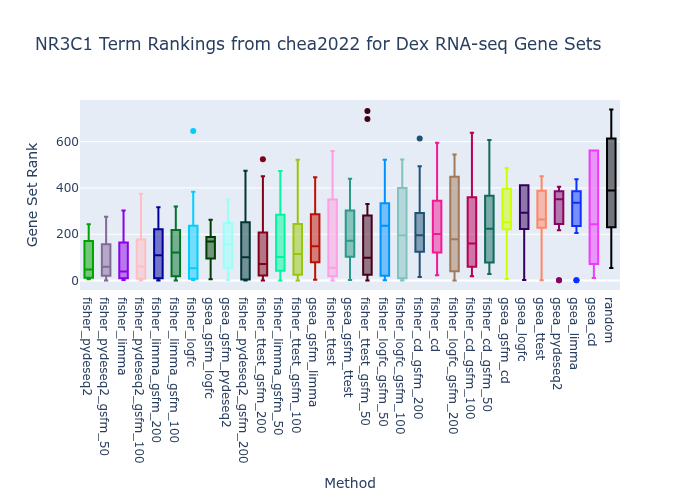

In [58]:
import glasbey
ensure_list = lambda x: [x] if type(x) != list else x
method_color_map = dict(zip(['random', *dex_chea2022_df['Method'].unique()], glasbey.extend_palette(['#000000'], len(dex_chea2022_df['Method'].unique())+1, colorblind_safe=True)))
for (tf, library), sub_df in dex_chea2022_df.groupby(['TF', 'Library']):
    if library != 'chea2022' :continue
    if tf != 'NR3C1': continue
    sub_df = sub_df.set_index(['Method'])
    sub_df = sub_df[sub_df['Term'].apply(lambda x: 'MLEC' not in x)]
    fig1 = go.Figure()
    for gs in sub_df.groupby(['Method']).mean(numeric_only=True).sort_values('Rank').index:
        fig1.add_trace(
            go.Box(
                y=ensure_list(sub_df.loc[gs]['Rank'].tolist()),
                name=gs, 
                marker_color=method_color_map[gs.split(':')[0]]
            )
        )
    sub_rand_df = rand_chea2022_df[rand_chea2022_df['TF'] == tf]
    fig1.add_trace(
        go.Box(
            y=sub_rand_df['Rank'].tolist(),
            name='random',
            marker_color='black'
        )
    )

    fig1.update_layout(
        width=700,
        title_text=f"{tf} Term Rankings from {library} for Dex RNA-seq Gene Sets",
        xaxis={
            'title': {'text': 'Method'}, 
        },
        yaxis={
            'title': {'text': 'Gene Set Rank'}
        },
        showlegend=False
    )
    fig1.write_image(f"{data_dir}/N3RC1-ChEA2022-SetRank.pdf")
    fig1.show('png')

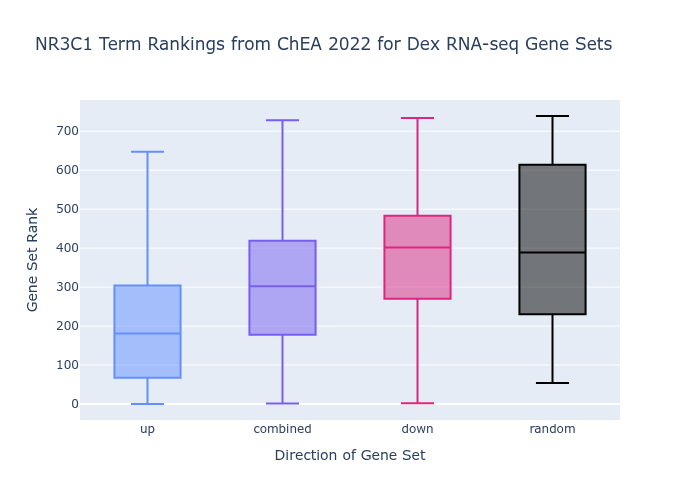

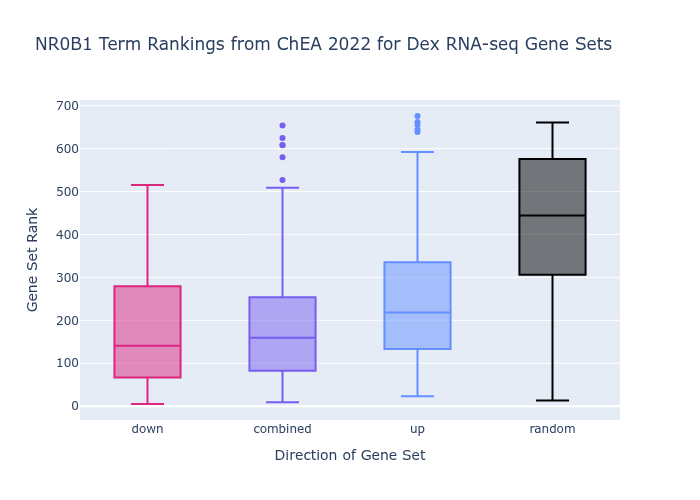

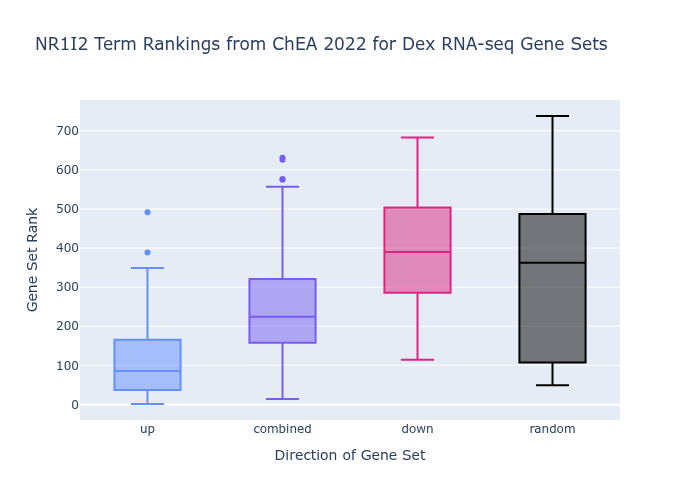

In [37]:
# color-blind friendly
method_color_map = {
    'up': '#648FFF',
    'down': '#DC267F', 
    'combined': '#785EF0'
}
for tf in dex_chea2022_df['TF'].unique():
    sub_df = dex_chea2022_df[dex_chea2022_df['TF']==tf].set_index(['Direction'])
    sub_df = sub_df[sub_df['Term'].apply(lambda x: 'MLEC' not in x and 'WistarRat' not in x)]
    fig1 = go.Figure()
    for gs in sub_df.groupby(['Direction']).mean(numeric_only=True).sort_values('Rank').index:
        fig1.add_trace(
            go.Box(
                y=sub_df.loc[gs]['Rank'].tolist(),
                name=gs, 
                marker_color=method_color_map[gs]
            )
        )
    sub_rand_df = rand_chea2022_df[rand_chea2022_df['TF'] == tf]
    fig1.add_trace(
        go.Box(
            y=sub_rand_df['Rank'].tolist(),
            name='random',
            marker_color='black'
        )
    )

    fig1.update_layout(
        width=700,
        title_text=f"{tf} Term Rankings from ChEA 2022 for Dex RNA-seq Gene Sets",
        xaxis={
            'title': {'text': 'Direction of Gene Set'}, 
        },
        yaxis={
            'title': {'text': 'Gene Set Rank'}
        },
        showlegend=False
    )
    fig1.show("png")
    if tf == 'NR3C1': 
        fig1.write_image(f'{data_dir}/2A_300dpi.png', scale=(800/300))

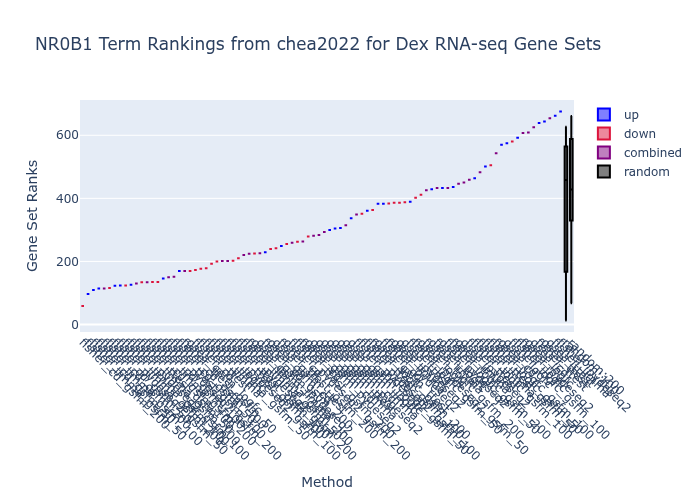

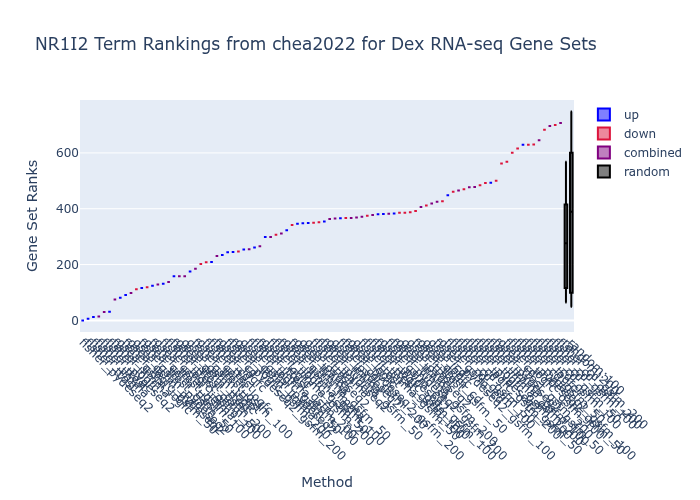

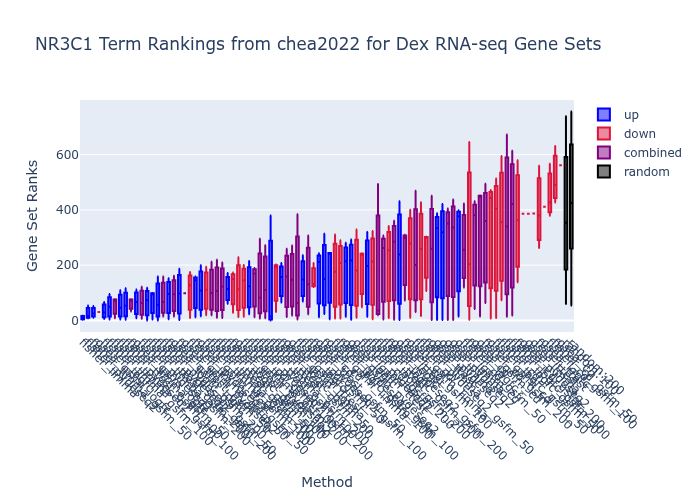

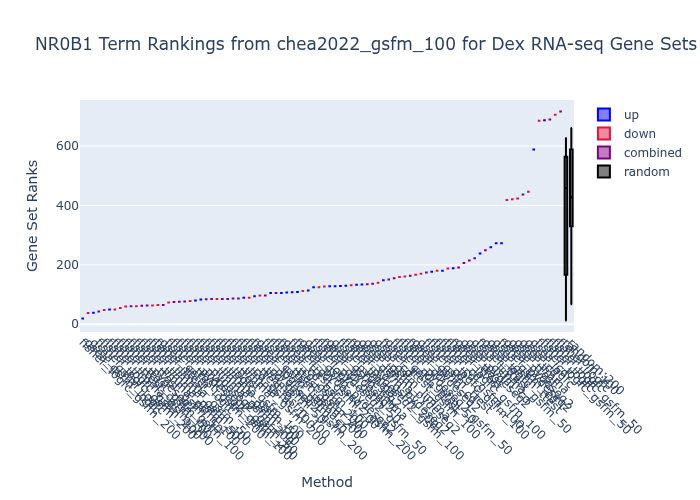

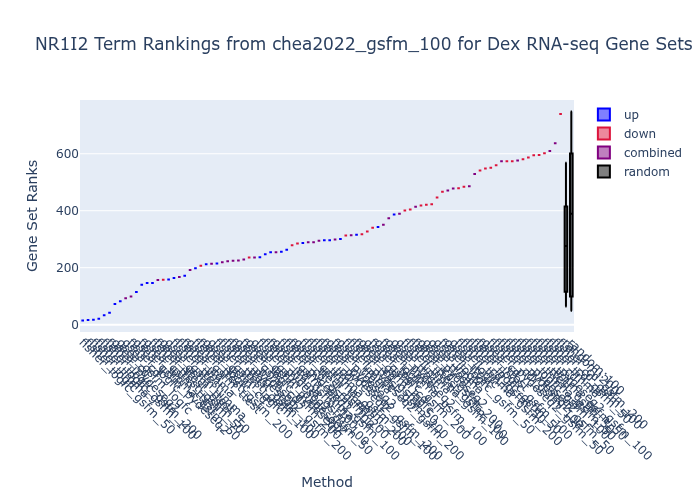

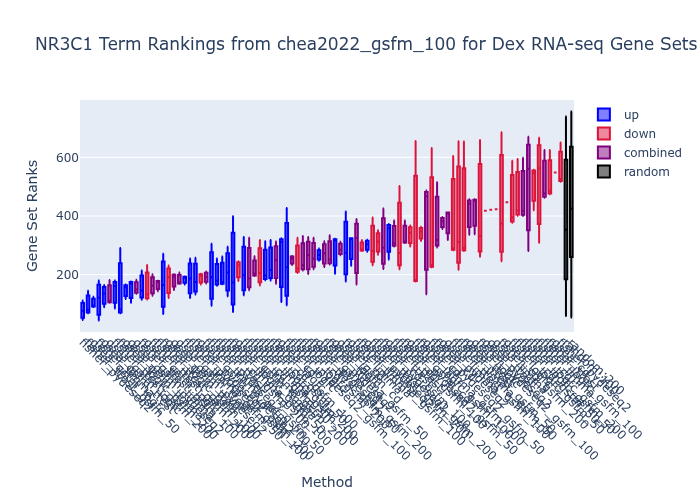

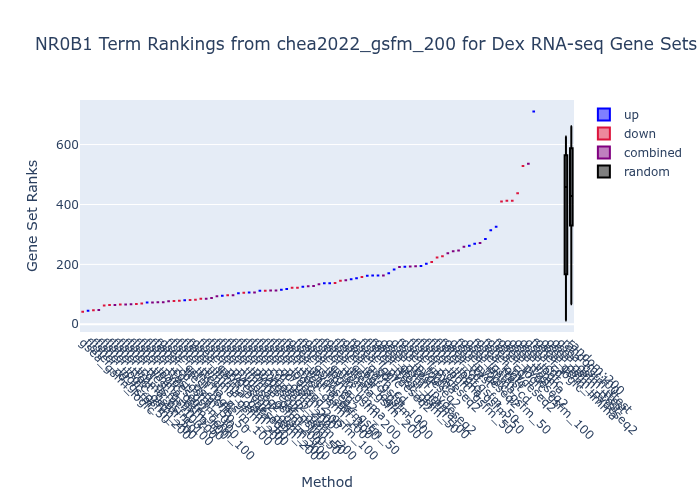

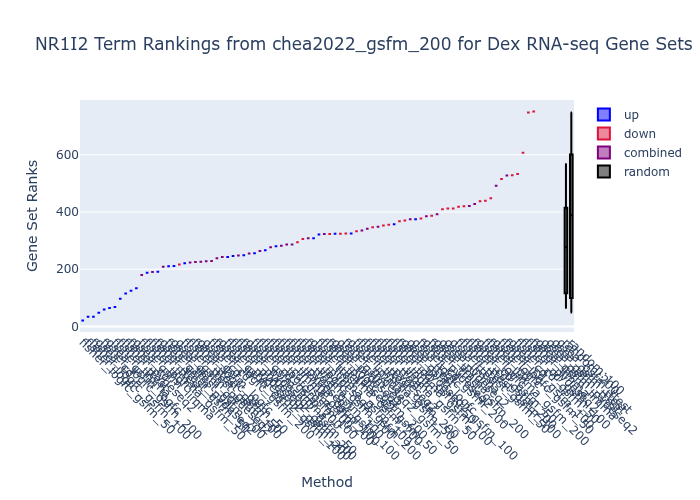

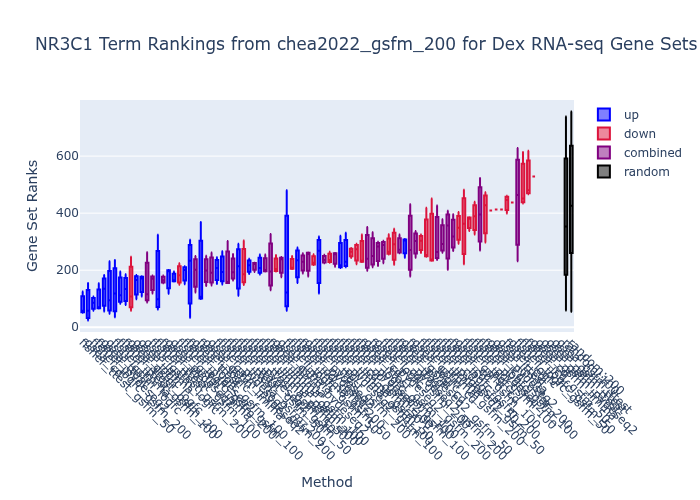

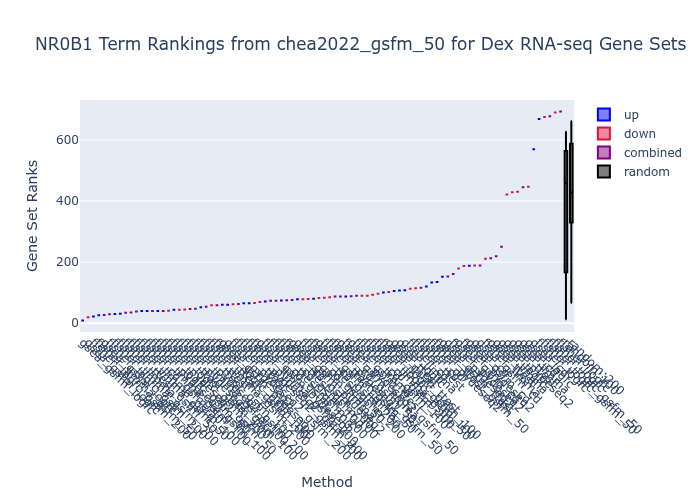

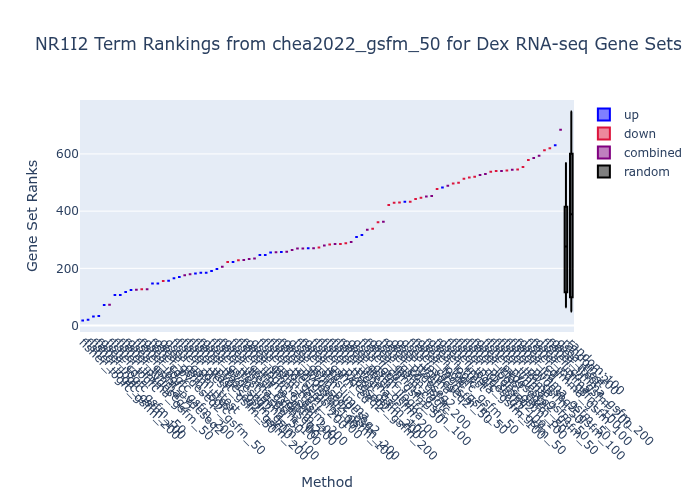

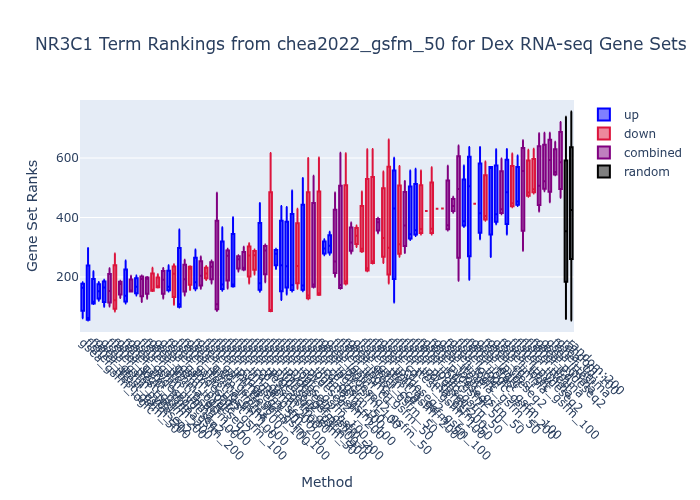

In [ ]:
method_color_map = {
    'up': 'blue',
    'down': 'crimson',
    'combined': 'purple'
}

for (library, tf), sub_df in dex_chea2022_df.groupby(['Library', 'TF']):
    sub_df = sub_df[sub_df['Term'].apply(lambda x: 'MLEC' not in x and 'WistarRat' not in x)]
    x_order = sub_df.groupby(['Gene_Set']).mean(numeric_only=True).sort_values('Rank').reset_index().rename_axis('Order').reset_index().set_index('Gene_Set')
    x_order['Labels'] = x_order.index.map(lambda x: x.split(':')[0]).tolist()
    fig1 = go.Figure()
    for d in sub_df['Direction'].unique(): 
        d_df = sub_df[sub_df['Direction'] == d]
        fig1.add_trace(
            go.Box(
                x=[x_order.loc[x, 'Order'] for x in d_df['Gene_Set']],
                y=d_df['Rank'],
                name=d, 
                marker_color=method_color_map[d]
            )
        )
    sub_rand_df = rand_chea2022_df[rand_chea2022_df['TF'] == tf]
    rand_x_order = sub_rand_df.groupby(['Gene_Set']).mean(numeric_only=True).sort_values('Rank').reset_index()
    rand_x_order['Order'] = [x + x_order.shape[0] for x in rand_x_order.index.tolist()]
    rand_x_order['Labels'] = rand_x_order['Gene_Set'].tolist()
    rand_x_order = rand_x_order.set_index('Gene_Set')
    fig1.add_trace(
        go.Box(
            x=[rand_x_order.loc[x, 'Order'] for x in sub_rand_df['Gene_Set']],
            y=sub_rand_df['Rank'],
            name='random',
            marker_color='black'
        )
    )
    fig1.update_layout(
        # width=800,
        title_text=f"{tf} Term Rankings from {library} for Dex RNA-seq Gene Sets",
        xaxis={
            'title': {'text': 'Method'}, 
        },
        yaxis={
            'title': {'text': 'Gene Set Ranks'}
        }
    )
    fig1.update_xaxes(
        tickmode='array',
        tickangle=45,
        tickvals = x_order['Order'].tolist() + rand_x_order['Order'].tolist(),
        ticktext=x_order['Labels'].tolist() + rand_x_order['Labels'].tolist()
    )
    fig1.show("png")

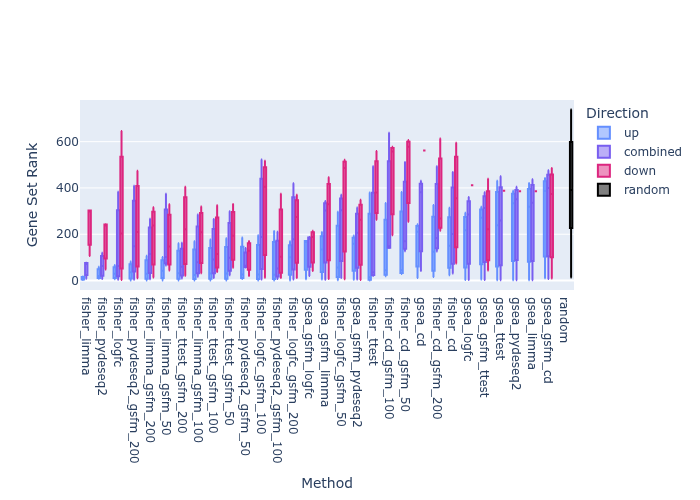

In [38]:
# color-blind friendly
method_color_map = {
    'up': '#648FFF',
    'down': '#DC267F', 
    'combined': '#785EF0'
}
for (tf, library), sub_df in dex_chea2022_df.groupby(['TF', 'Library']):
    if library != 'chea2022' or tf != 'NR3C1': continue
    fig1 = go.Figure()
    sub_df = sub_df[sub_df['Term'].apply(lambda x: 'MLEC' not in x and 'WistarRat' not in x)]
    order = sub_df.groupby('Gene_Set').mean(numeric_only=True).sort_values('Rank').index.map(lambda x: x.split(':')[0]).unique()
    sub_df['Method'] = pd.Categorical(sub_df['Method'], order)
    sub_df = sub_df.sort_values(by=['Method'])
    for d in ['up', 'combined', 'down']:
        fig1.add_trace(go.Box(
            x=sub_df[sub_df['Direction'] == d]['Method'],
            y=sub_df[sub_df['Direction'] == d]['Rank'],
            name=d, 
            marker_color=method_color_map[d]
        ))
    fig1.add_trace(go.Box(
        x=rand_df['Method'],
        y=rand_df['Rank'],
        name='random', 
        marker_color='black'
    ))
    fig1.update_layout(
        width=800,
        boxmode='group',
        boxgap=0.15,
        xaxis={
            'title': {'text': 'Method'}, 
        },
        yaxis={
            'title': {'text': 'Gene Set Rank'}
        },
        legend_title_text="Direction"
    )
    fig1.show("png")

In [ ]:
method_color_map = dict(zip(['random', *dex_chea2022_df['Method'].unique()], glasbey.extend_palette(['#000000'], len(dex_chea2022_df['Method'].unique())+1, colorblind_safe=True)))

for tf in dex_chea2022_df['TF'].unique():
    sub_df = dex_chea2022_df[dex_chea2022_df['TF']==tf]
    sub_df = sub_df[sub_df['Term'].apply(lambda x: 'MLEC' not in x and 'WistarRat' not in x)]
    order = sub_df.groupby('Gene_Set').mean(numeric_only=True).sort_values('Rank').index.map(lambda x: x.split(':')[0]).unique()
    sub_df['Method'] = pd.Categorical(sub_df['Method'], order)
    sub_df['Direction'] = pd.Categorical(sub_df['Direction'], ['up', 'combined', 'down'])
    sub_df = sub_df.sort_values(by=['Direction', 'Method'])

    fig1 = go.Figure()
    for method in sub_df['Method'].unique(): 
      m_df = sub_df[sub_df['Method'] == method]
      fig1.add_trace(go.Box(
          x=m_df[m_df['Method'] == method]['Direction'],
          y=m_df[m_df['Method'] == method]['Rank'],
          name=method, 
          marker_color=method_color_map[method]
      ))
    sub_rand_df = rand_df[rand_df['TF'] == tf]
    fig1.add_trace(go.Box(
      x=sub_rand_df['Method'],
      y=sub_rand_df['Rank'],
      name='random', 
      marker_color='black'
    ))
    fig1.update_layout(
      width=800,
      boxmode='group',
      boxgap=0.1,
      xaxis={
          'title': {'text': 'Direction'}, 
      },
      yaxis={
          'title': {'text': 'Gene Set Rank'}
      },
      legend_title_text="Method"
    )
    fig1.show()    
    if tf == 'NR3C1': 
        fig1.write_image(f'{data_dir}/2D_300dpi.png', scale=(800/300))

## Bridge plots

The below plots provide the Brownian bridge plots comparing the ranked genes from each method signature with the genes in the target TF gene sets.

In [39]:
target_genesets = []
target_genesets.append({t:chea2022[t] for t in dex_chea2022_df['Term'].unique() if 'MLEC' not in t})

In [40]:
methods = list(signatures)
more_signatures = {}
for dir, sigs in [('up', up_gsfm_signatures), ('down', down_gsfm_signatures), ('combined', combined_gsfm_signatures)]:
  for method in methods:
    d = sigs[method]
    d.name = 'Significance'
    d = d.to_frame()
    more_signatures[f"gsfm_{method}_{dir}"] = d

In [41]:
def singleBridgePlot(gsname, signame, target_gs):
    geneset = target_gs[gsname]
    if signame in signatures:
        if signame == 'cd' or signame == 'logfc':
            sorted_genes = signatures[signame].sort_values(by='Significance', ascending=False)
        else: 
            sorted_genes = signatures[signame].sort_values(by=['Significance'], ascending=True)
    else:
        sorted_genes = more_signatures[signame].sort_values(by='Significance', ascending=False)
    select = pd.Series(
        [x.upper() in geneset for x in sorted_genes.index.tolist()]
    )
    x, y = bridge_plot(select)
    x = x/len(x)
    return x,y

def randomBridgePlot(gsname, target_gs): 
    all_x = []
    all_y = []

    for _ in range(10):
        rand_sig = sample(
            signatures['logfc'].index.tolist(), 
            signatures['logfc'].shape[0]
        )
        select = pd.Series([
            x.upper() in target_gs[gsname] for x in rand_sig
        ])
        x, y = bridge_plot(select)
        x = x/len(x)
        all_x.append(x)
        all_y.append(y)

    return all_x, all_y

In [42]:
def build_tf_res(target_gs):
    tf_res = {tf: {'random': {'x': [], 'y': []}} for tf in full_df['TF'].unique()}
    for gs in target_gs.keys():
        tf = gs.split(' ')[0].split('_')[0]
        rand_x, rand_y = randomBridgePlot(gs, target_gs)
        tf_res[tf]['random']['x'] += rand_x
        tf_res[tf]['random']['y'] += rand_y
        for sig in signatures.keys() | more_signatures.keys():
            temp_x, temp_y = singleBridgePlot(gs, sig, target_gs)
            if sig in tf_res[tf].keys():
                tf_res[tf][sig]['x'].append(temp_x)
                tf_res[tf][sig]['y'].append(temp_y)
            else: 
                tf_res[tf][sig] = {'x': [temp_x], 'y': [temp_y]}
    return tf_res

In [43]:
significance_tf_results = [] 
for i in range(len(target_genesets)): 
    significance_tf_results.append(build_tf_res(target_genesets[i]))

In [44]:
libraries = ['chea2022']

In [45]:
keys, colors = zip(*method_color_map.items())
new_keys = list(keys) + list((signatures.keys()|more_signatures.keys()) - set(keys))
new_colors = glasbey.extend_palette(colors, len(keys)+len(new_keys), colorblind_safe=True)
bridge_color_map = dict(zip(new_keys, new_colors))

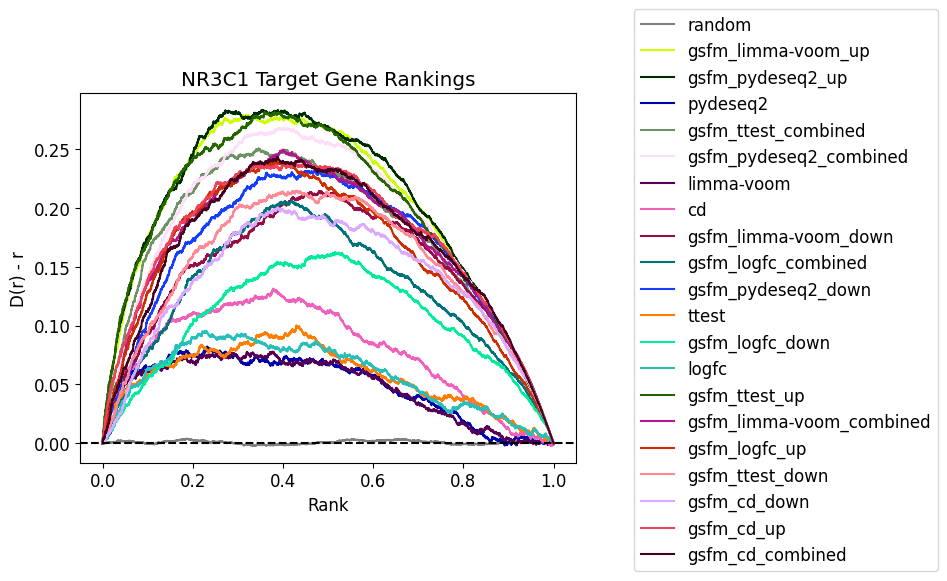

In [53]:
# with opposite direction queries
mpl.rcParams.update({'font.size': 12})
for tf in full_df['TF'].unique():
    if tf != 'NR3C1': continue
    fig = plt.figure()
    tf_x = {method: [] for method in significance_tf_results[0][tf].keys()}
    tf_y = {method: [] for method in significance_tf_results[0][tf].keys()}
    for i in range(len(target_genesets)):
      for sig in significance_tf_results[i][tf].keys(): 
        tf_x[sig].append(np.mean(significance_tf_results[i][tf][sig]['x'], axis=0))
        tf_y[sig].append(np.mean(significance_tf_results[i][tf][sig]['y'], axis=0))
    for m in tf_x.keys():
      if m == 'random': 
          plt.plot(np.mean(tf_x[m], axis=0), np.mean(tf_y[m], axis=0), label=m, color='gray')
      elif m == 'cd' or m == 'logfc': 
          plt.plot(np.mean(tf_x[m], axis=0), np.mean(tf_y[m], axis=0), label=m, color=bridge_color_map[m])
      else:
          label = m.replace('limma', 'limma-voom')
          plt.plot(np.mean(tf_x[m], axis=0), np.mean(tf_y[m], axis=0), label=label, color=bridge_color_map[m])

    plt.axhline(y=0, color='black', linestyle='dashed')
    plt.legend(bbox_to_anchor=(1.1, 1.25))
    plt.title(f"{tf} Target Gene Rankings")
    plt.xlabel('Rank')
    plt.ylabel('D(r) - r')
    plt.savefig(f'{data_dir}/N3RC1BridgePlot.pdf', bbox_inches='tight')
    plt.show()
    
    # if tf == 'NR3C1':
    #     fig.savefig(f'{data_dir}/Figure2E.png', format='png', dpi=300, bbox_inches='tight')

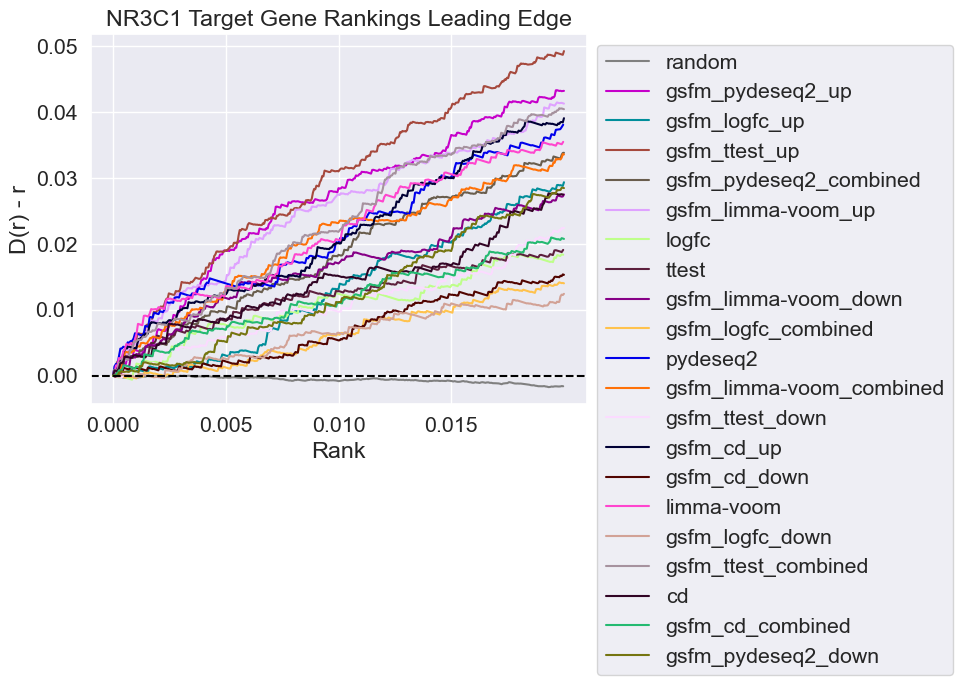

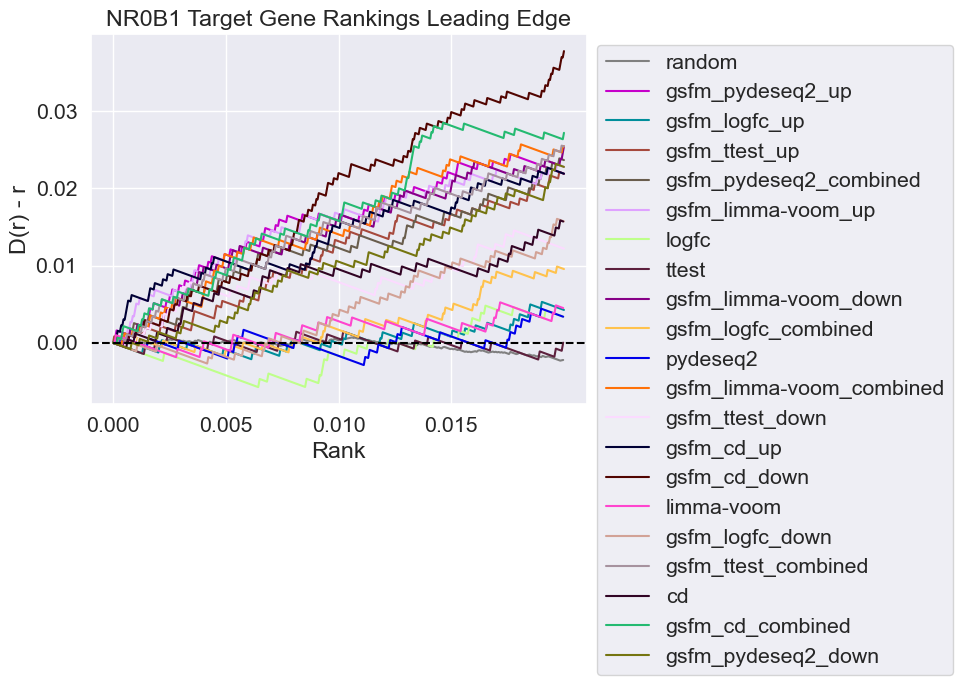

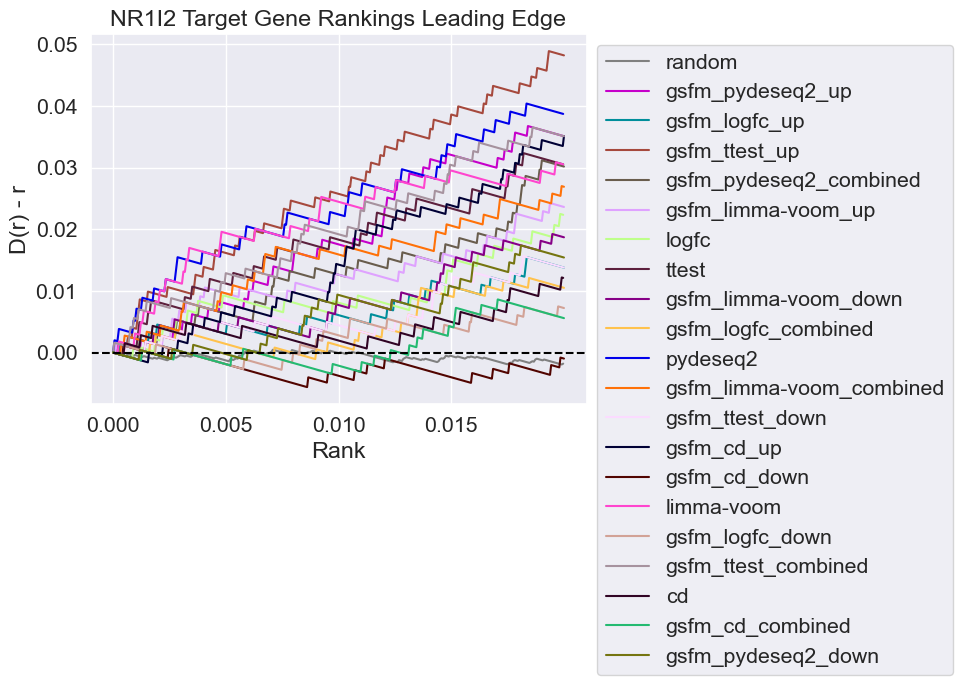

In [ ]:
# with manual libraries
mpl.rcParams.update({'font.size': 12})
for tf in full_df['TF'].unique():
    fig = plt.figure()
    tf_x = {method: [] for method in significance_tf_results[0][tf].keys()}
    tf_y = {method: [] for method in significance_tf_results[0][tf].keys()}
    for i in range(len(libraries)):
      for sig in significance_tf_results[i][tf].keys(): 
        tf_x[sig].append(np.mean(significance_tf_results[i][tf][sig]['x'], axis=0))
        tf_y[sig].append(np.mean(significance_tf_results[i][tf][sig]['y'], axis=0))
    for m in tf_x.keys():
      try:
        leading_x = [arr[:ceil(0.02*len(arr))] for arr in tf_x[m]]
        leading_y = [arr[:ceil(0.02*len(arr))] for arr in tf_y[m]]
      except:
        leading_x = tf_x[m][0][:ceil(0.02*len(tf_x[m][0]))]
        leading_y = tf_y[m][0][:ceil(0.02*len(tf_y[m][0]))]
      if m == 'random': 
        plt.plot(np.mean(leading_x, axis=0), np.mean(leading_y, axis=0), label=m, color='gray')
      elif m == 'cd' or m == 'logfc': 
          plt.plot(np.mean(leading_x, axis=0), np.mean(leading_y, axis=0), label=m, color=bridge_color_map[m])
      else:
        label = m.replace('limma', 'limma-voom')
        plt.plot(np.mean(leading_x, axis=0), np.mean(leading_y, axis=0), label=label, color=bridge_color_map[m])

    plt.axhline(y=0, color='black', linestyle='dashed')
    plt.legend(bbox_to_anchor=(1, 1))
    plt.title(f"{tf} Target Gene Rankings Leading Edge")
    plt.xlabel('Rank')
    plt.xticks(np.arange(0, 0.02, step=0.005))
    plt.ylabel('D(r) - r')
    plt.show()

    # if tf == 'NR3C1': 
    #   fig.savefig(f'{data_dir}/Figure2F.png', format='png', dpi=300, bbox_inches='tight')

## Signature similarity

In [ ]:
rank_comparison = pd.concat([
  signatures['cd']['CD-coefficient'].rename('CD').rank(),
  signatures['limma']['t'].rename('Limma').rank(),
  signatures['pydeseq2']['stat'].rename('DESeq2').rank(),
  signatures['logfc']['logFC'].apply(abs).rename('FC').rank(),
  signatures['ttest']['Statistic'].rename('Ttest').rank(),
  *[more_signatures[k]['Significance'].fillna(1).rename(k).rank() for k in more_signatures],
], axis=1).dropna()

In [ ]:
expr_comparison = pd.concat([
  signatures['cd']['CD-coefficient'].rename('CD'),
  signatures['limma']['t'].rename('Limma'),
  signatures['pydeseq2']['stat'].rename('DESeq2'),
  signatures['logfc']['logFC'].apply(abs).rename('FC'),
  signatures['ttest']['Statistic'].rename('Ttest'),
  *[more_signatures[k]['Significance'].fillna(1).rename(k) for k in more_signatures],
], axis=1).dropna()

In [ ]:
sns.set(font_scale=1.4)

### Correlation of signature expression values

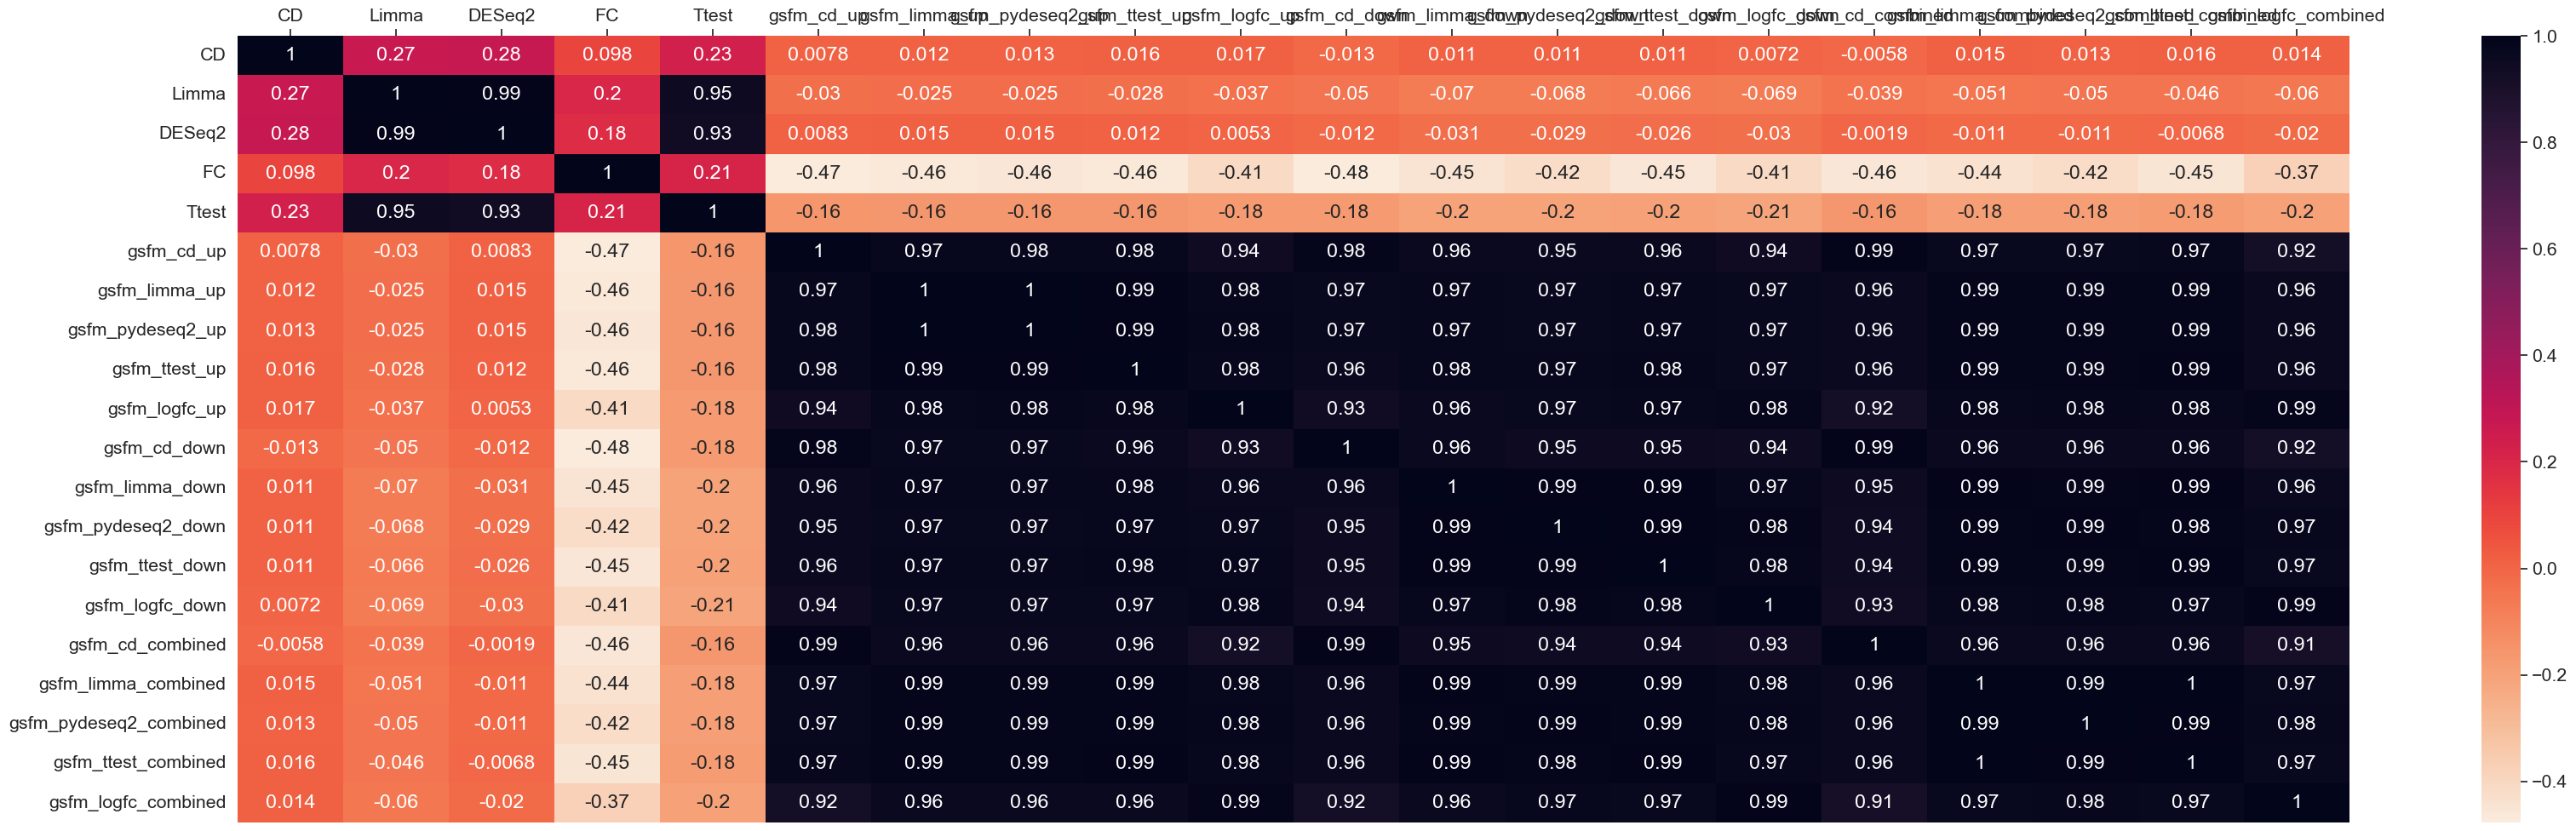

In [ ]:
expr_correlations = 1-pairwise_distances(
  expr_comparison.T, metric='cosine'
)
np.fill_diagonal(expr_correlations, 1)

hm, hm_ax = plt.subplots(figsize=(40,12))  
sns.heatmap(pd.DataFrame(
  expr_correlations, index=expr_comparison.columns, columns=expr_comparison.columns
), cmap=sns.cm.rocket_r, annot=True)
hm_ax.xaxis.tick_top()

### Correlation of signature gene ranks

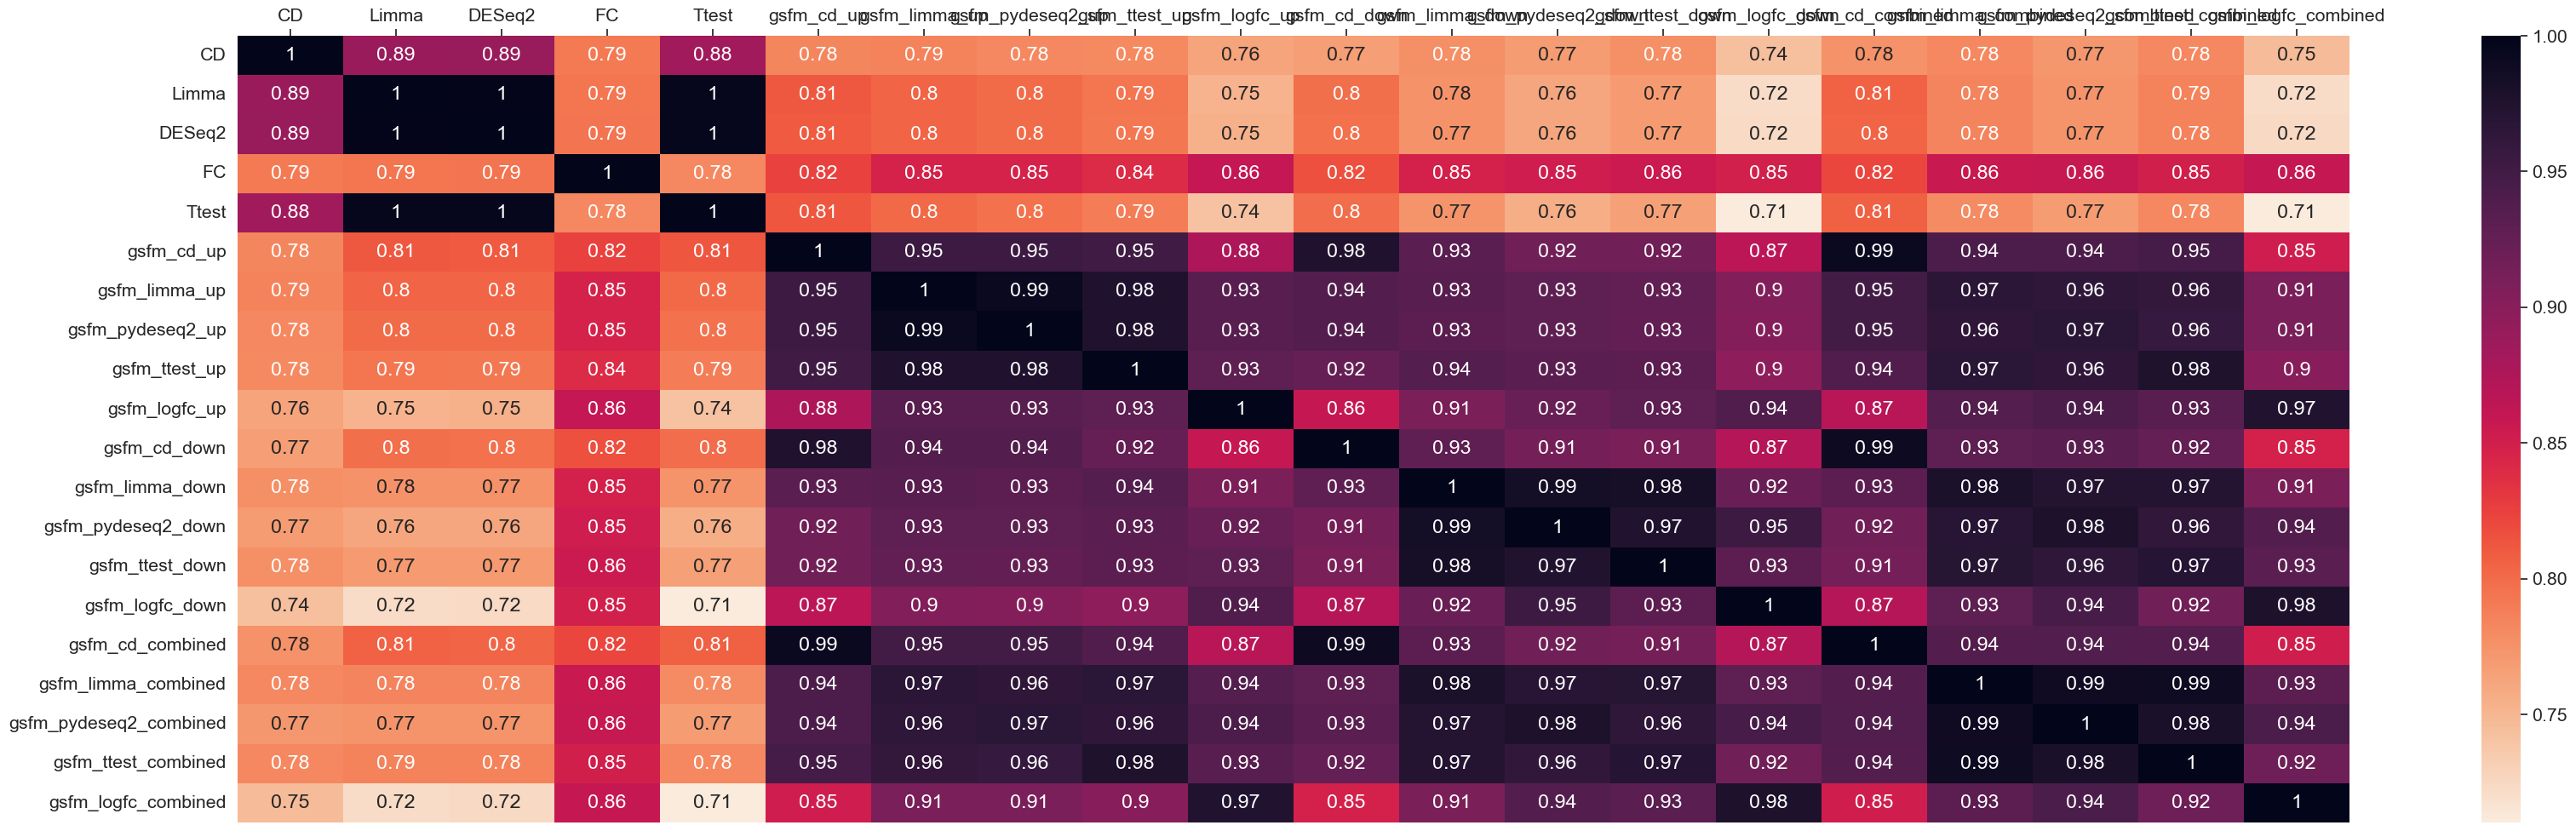

In [ ]:
rank_correlations = 1-pairwise_distances(
  rank_comparison.T, metric='cosine'
)
np.fill_diagonal(rank_correlations, 1)

hm, hm_ax = plt.subplots(figsize=(40,12))  
sns.heatmap(pd.DataFrame(
  rank_correlations, index=rank_comparison.columns, columns=rank_comparison.columns
), cmap=sns.cm.rocket_r, annot=True)
hm_ax.xaxis.tick_top()